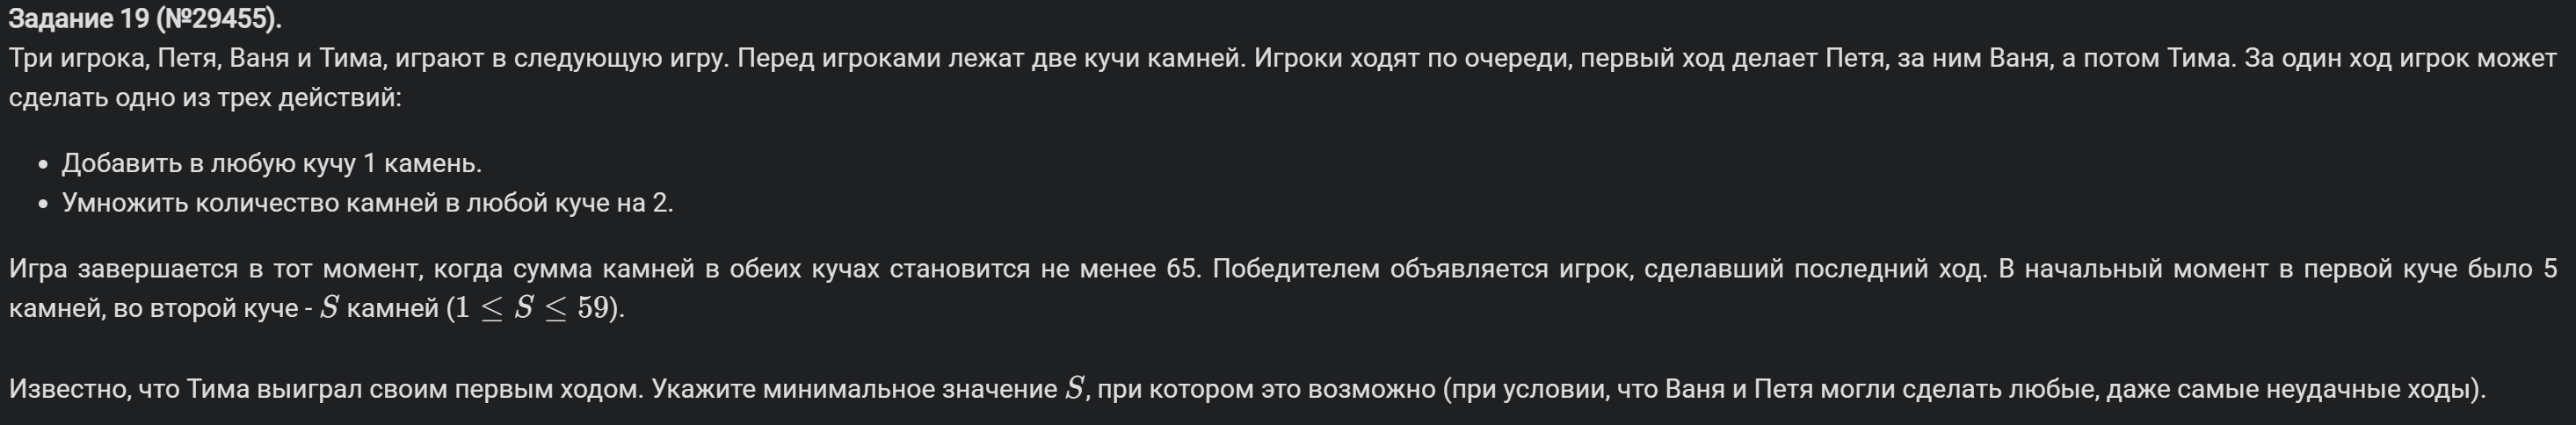

In [5]:
from functools import lru_cache

@lru_cache(None)
def f(a, b, move: str, goal: str, left: int):
    if a + b >= 65:
        return move != goal

    if move == "P":
        h = [f(a + 1, b, "V", goal, left - 1), f(a, b + 1, "V", goal, left - 1), f(a * 2, b, "V", goal, left - 1), f(a, b * 2, "V", goal, left - 1)]
    elif move == "V":
        h = [f(a + 1, b, "T", goal, left - 1), f(a, b + 1, "T", goal, left - 1), f(a * 2, b, "T", goal, left - 1), f(a, b * 2, "T", goal, left - 1)]
    else:
        h = [f(a + 1, b, "P", goal, left - 1), f(a, b + 1, "P", goal, left - 1), f(a * 2, b, "P", goal, left - 1), f(a, b * 2, "P", goal, left - 1)]
    
    if left == 0:
        return False

    return any(h)

for s in range(1, 60):
    if f(5, s, "P", "T", 3):
        print(s)
        break

8


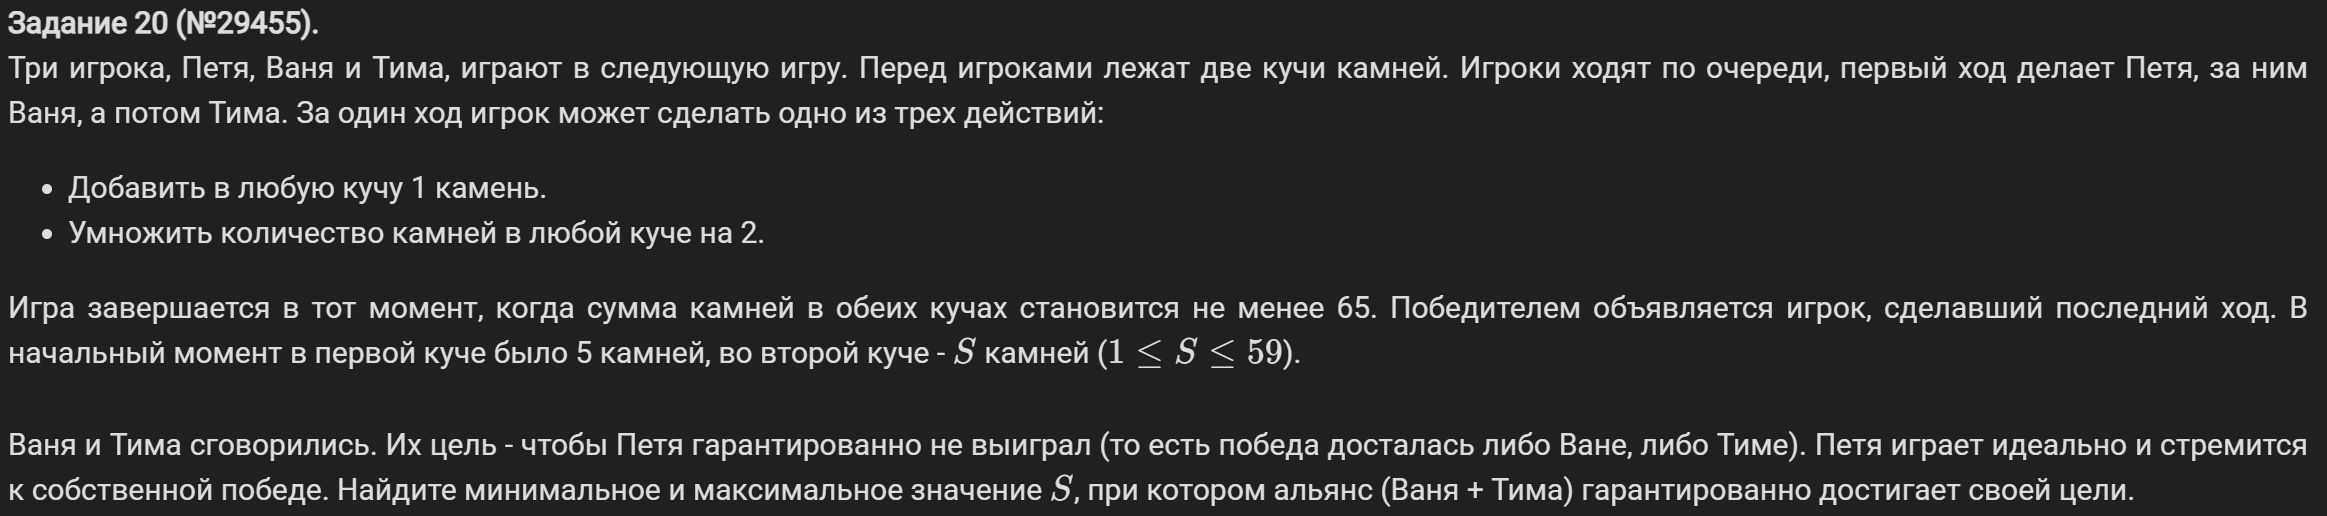

In [38]:
from functools import lru_cache

@lru_cache(None)
def f(a, b, move: str, goal: str, left: int):
    if a + b >= 65:
        return move not in goal

    if move == "P":
        h = [f(a + 1, b, "V", goal, left - 1), f(a, b + 1, "V", goal, left - 1), f(a * 2, b, "V", goal, left - 1), f(a, b * 2, "V", goal, left - 1)]
    elif move == "V":
        h = [f(a + 1, b, "T", goal, left - 1), f(a, b + 1, "T", goal, left - 1), f(a * 2, b, "T", goal, left - 1), f(a, b * 2, "T", goal, left - 1)]
    else:
        h = [f(a + 1, b, "P", goal, left - 1), f(a, b + 1, "P", goal, left - 1), f(a * 2, b, "P", goal, left - 1), f(a, b * 2, "P", goal, left - 1)]

    if left == 0:
        return False

    if move in goal:
        return any(h)
    return all(h)

res = []
for s in range(1, 60):
    for left in range(1, 31):
        if f(5, s, "P", "VT", left):
            res.append(s)
print(res[0], res[-1])

1 29


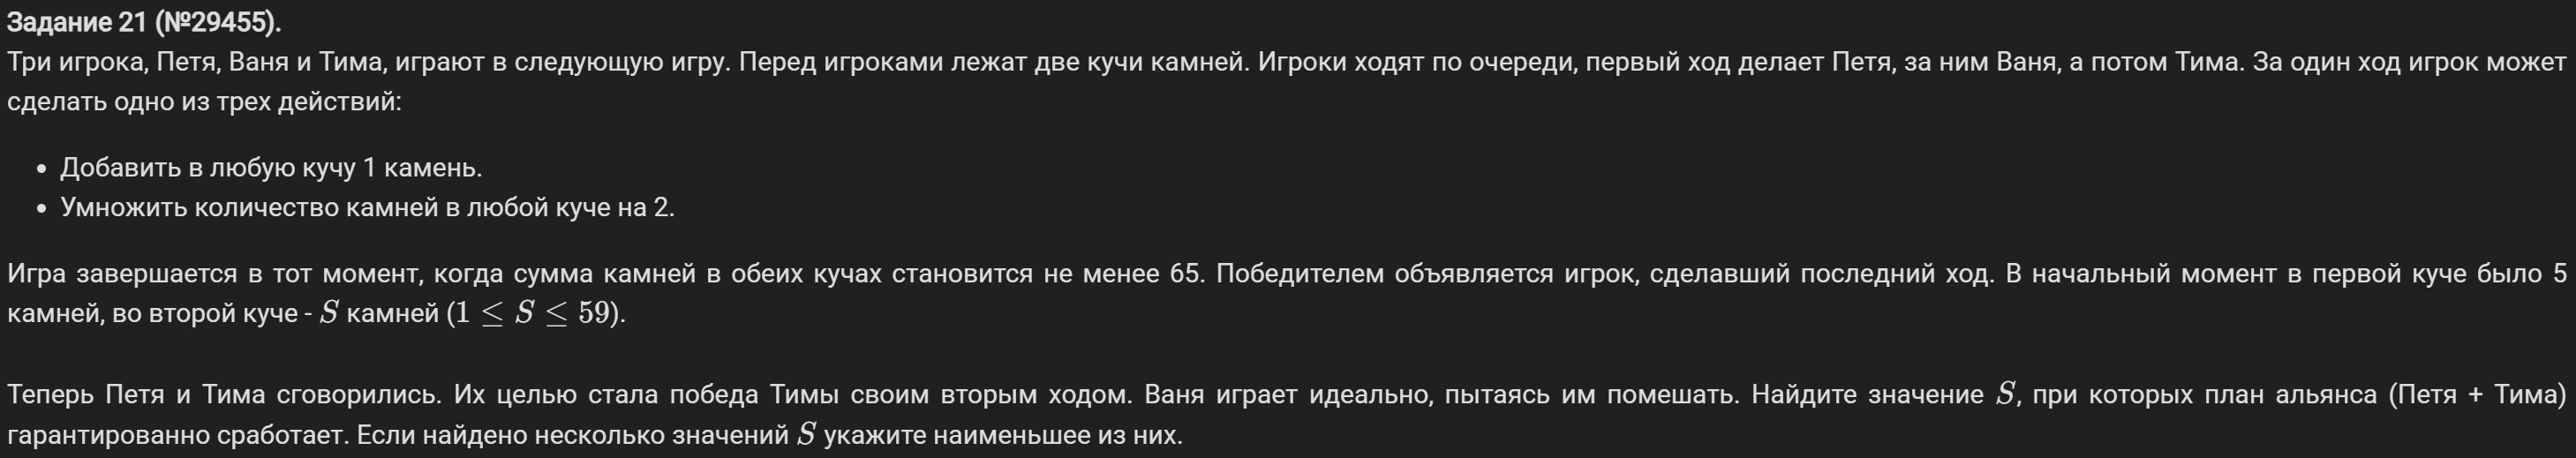

In [42]:
from functools import lru_cache

@lru_cache(None)
def f(a, b, move: str, goal: str, left: int):
    if a + b >= 65:
        return move == "P"

    if move == "P":
        h = [f(a + 1, b, "V", goal, left - 1), f(a, b + 1, "V", goal, left - 1), f(a * 2, b, "V", goal, left - 1), f(a, b * 2, "V", goal, left - 1)]
    elif move == "V":
        h = [f(a + 1, b, "T", goal, left - 1), f(a, b + 1, "T", goal, left - 1), f(a * 2, b, "T", goal, left - 1), f(a, b * 2, "T", goal, left - 1)]
    else:
        h = [f(a + 1, b, "P", goal, left - 1), f(a, b + 1, "P", goal, left - 1), f(a * 2, b, "P", goal, left - 1), f(a, b * 2, "P", goal, left - 1)]

    if left == 0:
        return False
    
    if move == "V":
        return all(h)
    return any(h)

for s in range(1, 60):
    if f(5, s, "P", "T", 6):
        print(s)
        break

10


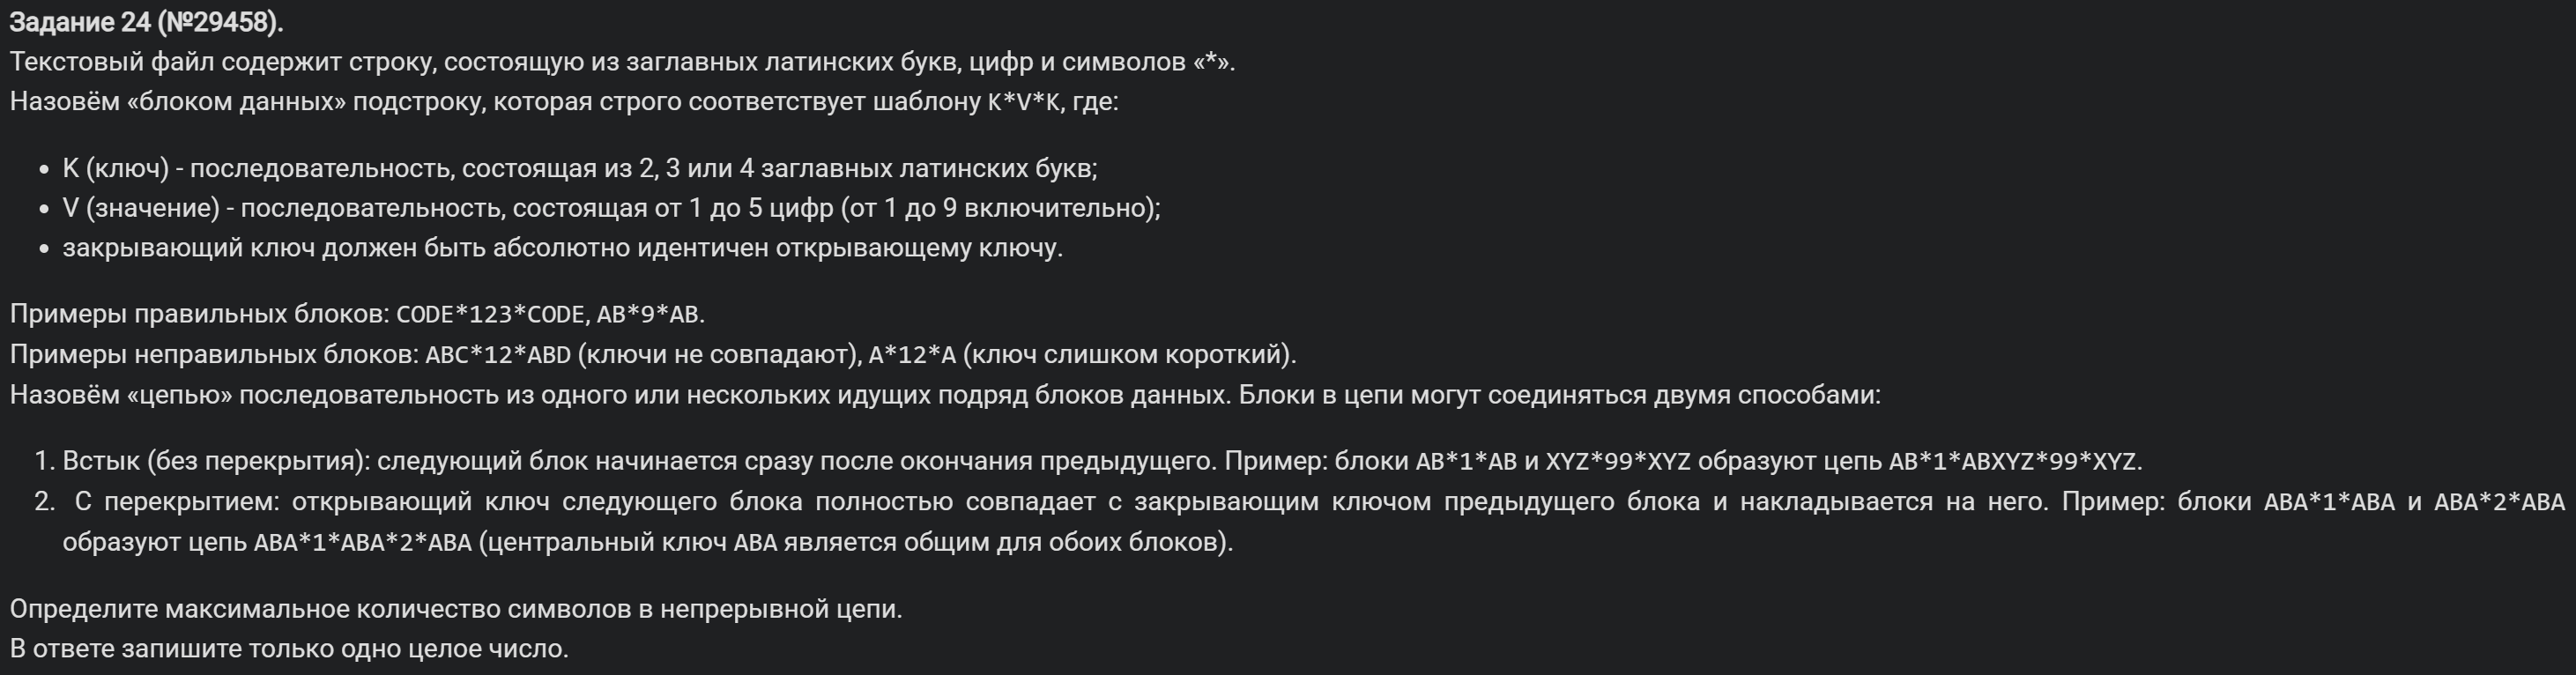

In [ ]:
from re import *
file = open(r"D:\informaticsclass\egeinfo\tests\grobetsky\24_29458.txt").readline()
file = file.split("*")
k = r"[A-Z]{2,4}"
v = r"[1-9]{1,5}"
lst = [i for i in file if match(k, i) or match(v, i)]
lst = [lst[0]] + [lst[i] for i in range(1, len(lst)) if not (lst[i - 1] == lst[i] and match(k, lst[i]))]
dp = [idx for idx in range(len(lst)) if match(k, lst[idx])]
# [(start, end), (start, end), (start, end), ...]
potential = []
start = None
for i in range(1, len(dp)):
    if dp[i] - dp[i - 1] == 2:
        if start is None:
            start = i - 1
    else:
        if start is not None:
            potential.append((start, i - 1))
            start = None
if start is not None:
    potential.append((start, len(dp) - 1))

mx = 0
for sublst in potential:
    left, right = dp[sublst[0]], dp[sublst[1]]
    keys = set([i for i in lst[left:right + 1] if match(k, i)])
    substr = "".join(lst[left:right + 1])
    for key in keys:
        pattern = f"(({key})({v}))+({key})"
        pattern = f"(?=({pattern}))"
        for i in finditer(pattern, substr):
            mx = max(mx, len(i.group(1)) + len(lst[left:right]) - 1)
print(mx)

1864


In [3]:
from re import *
file = open(r"D:\informaticsclass\egeinfo\tests\grobetsky\24_29458.txt").readline()
k = r"[A-Z]{2,4}"
v = r"[1-9]{1,5}"

blocks = [(m.start(), m.start() + len(m.group(1)), len(m.group(2)))
          for m in finditer(f'(?=(({k})\\*{v}\\*\\2))', file)]
print(blocks)
print(file[460:480])
best = {}
for s, e, kl in blocks:
    cs = min([s] + [best[p] for p in [s, s + kl] if p in best])
    if e not in best or best[e] > cs:
        best[e] = cs

print(max(e - best[e] for e in best))

[(125, 136, 3), (136, 145, 3), (145, 156, 4), (156, 165, 2), (165, 177, 4), (177, 185, 2), (185, 193, 2), (354, 365, 2), (363, 370, 2), (417, 429, 3), (429, 441, 3), (441, 454, 4), (450, 464, 4), (464, 477, 3), (474, 484, 3), (481, 493, 3), (490, 502, 3), (502, 515, 4), (515, 528, 4), (524, 535, 4), (531, 545, 4), (766, 778, 3), (775, 786, 3), (783, 796, 3), (793, 806, 3), (806, 817, 4), (813, 828, 4), (828, 835, 2), (833, 844, 2), (842, 853, 2), (851, 860, 2), (1029, 1038, 3), (1082, 1090, 2), (1090, 1104, 4), (1104, 1115, 3), (1115, 1126, 3), (1123, 1136, 3), (1133, 1144, 3), (1144, 1154, 3), (1151, 1163, 3), (1163, 1172, 2), (1172, 1183, 2), (1181, 1192, 2), (1192, 1203, 3), (1200, 1211, 3), (1211, 1225, 4), (1225, 1237, 3), (1285, 1296, 3), (1293, 1305, 3), (1302, 1312, 3), (1309, 1321, 3), (1318, 1328, 3), (1328, 1341, 4), (1341, 1352, 2), (1350, 1357, 2), (1355, 1364, 2), (1362, 1372, 2), (1372, 1383, 3), (1380, 1390, 3), (1387, 1397, 3), (1397, 1408, 3), (1408, 1416, 2), (1416, 

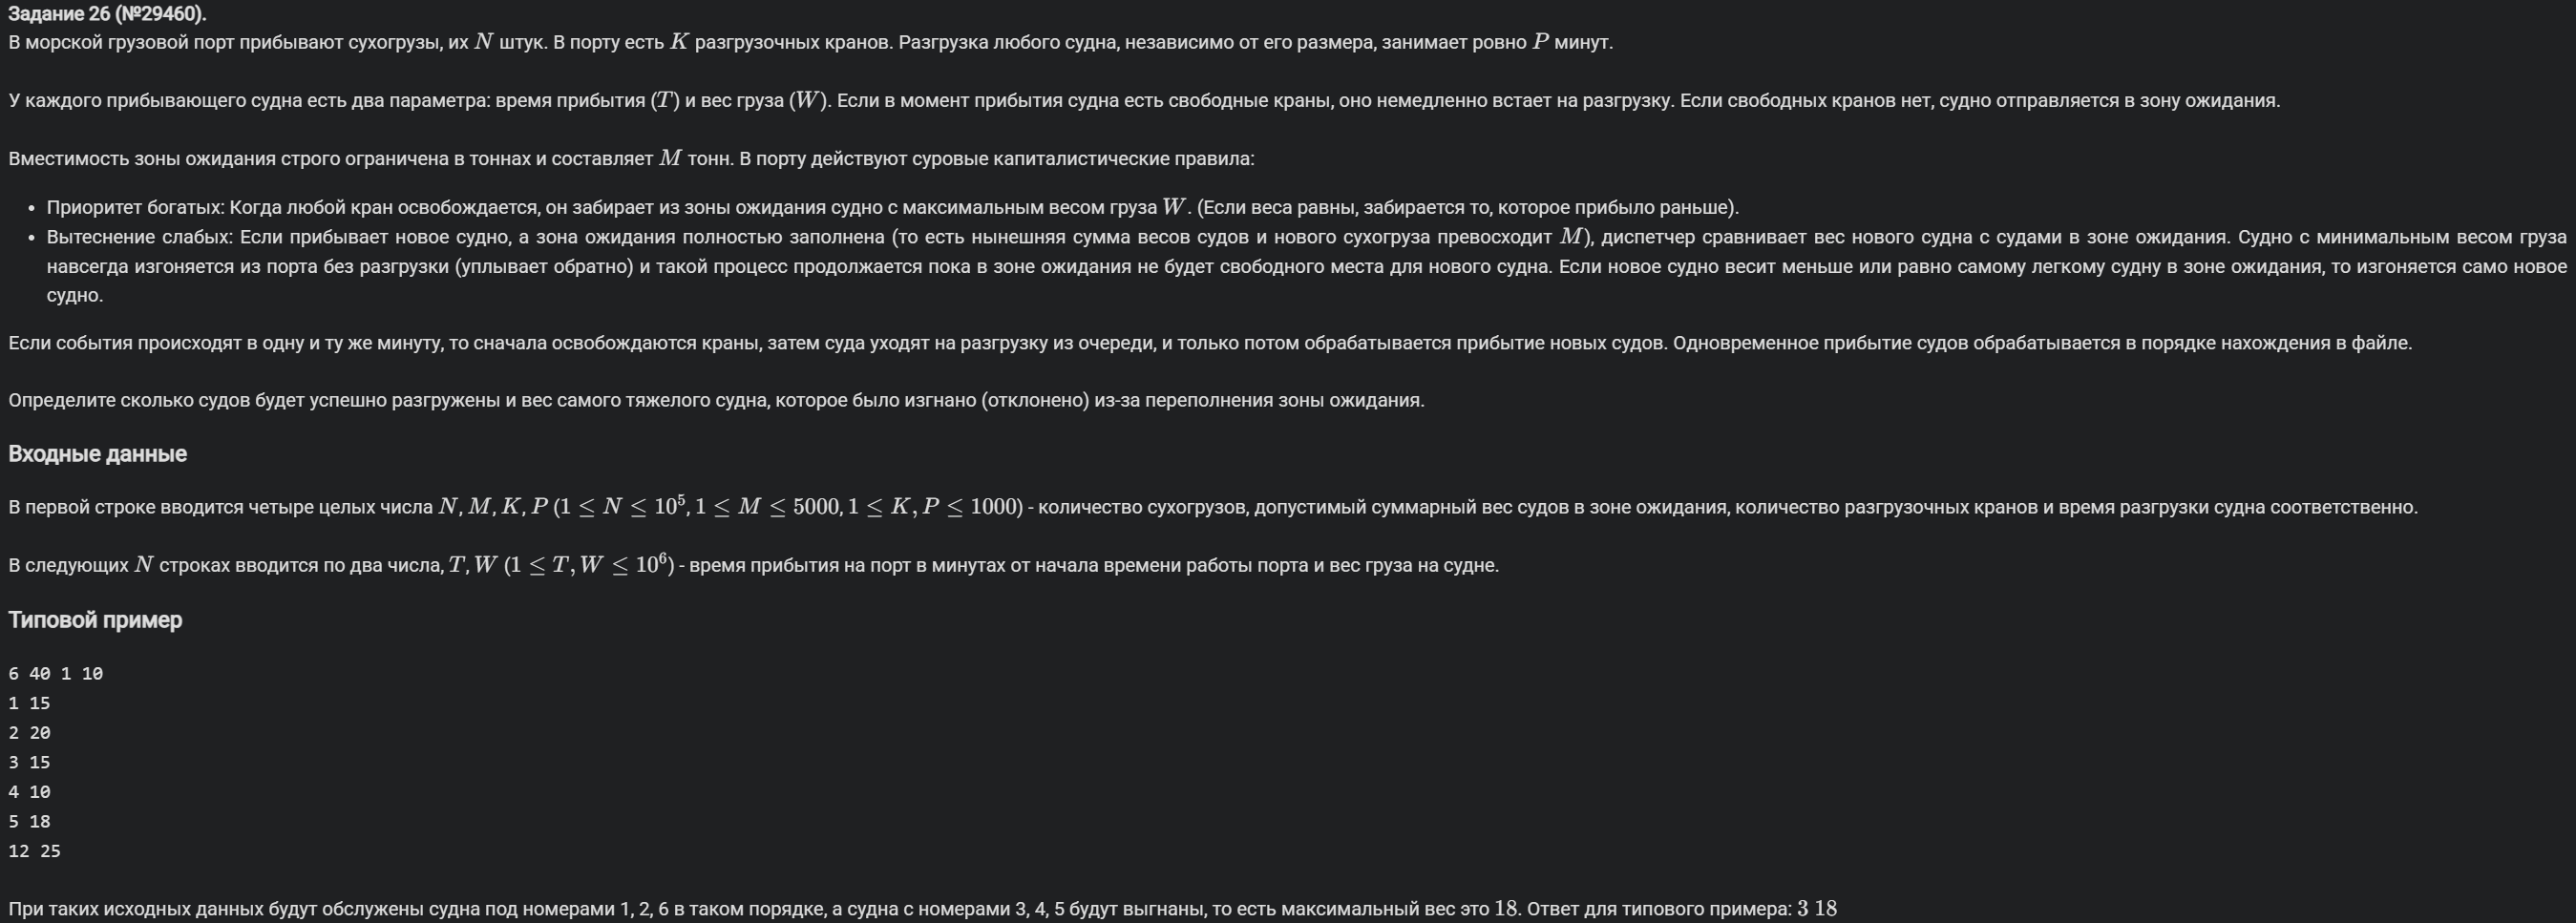

In [ ]:
file = open(r"D:\informaticsclass\egeinfo\tests\grobetsky\26_29460.txt")
n, mx_weight, cranes, load_time = map(int, file.readline().split(" "))
ships = [list(map(int, line.split(" "))) for line in file]
cranes = [0] * cranes
waiting_zone = []
denied = []


1


: 

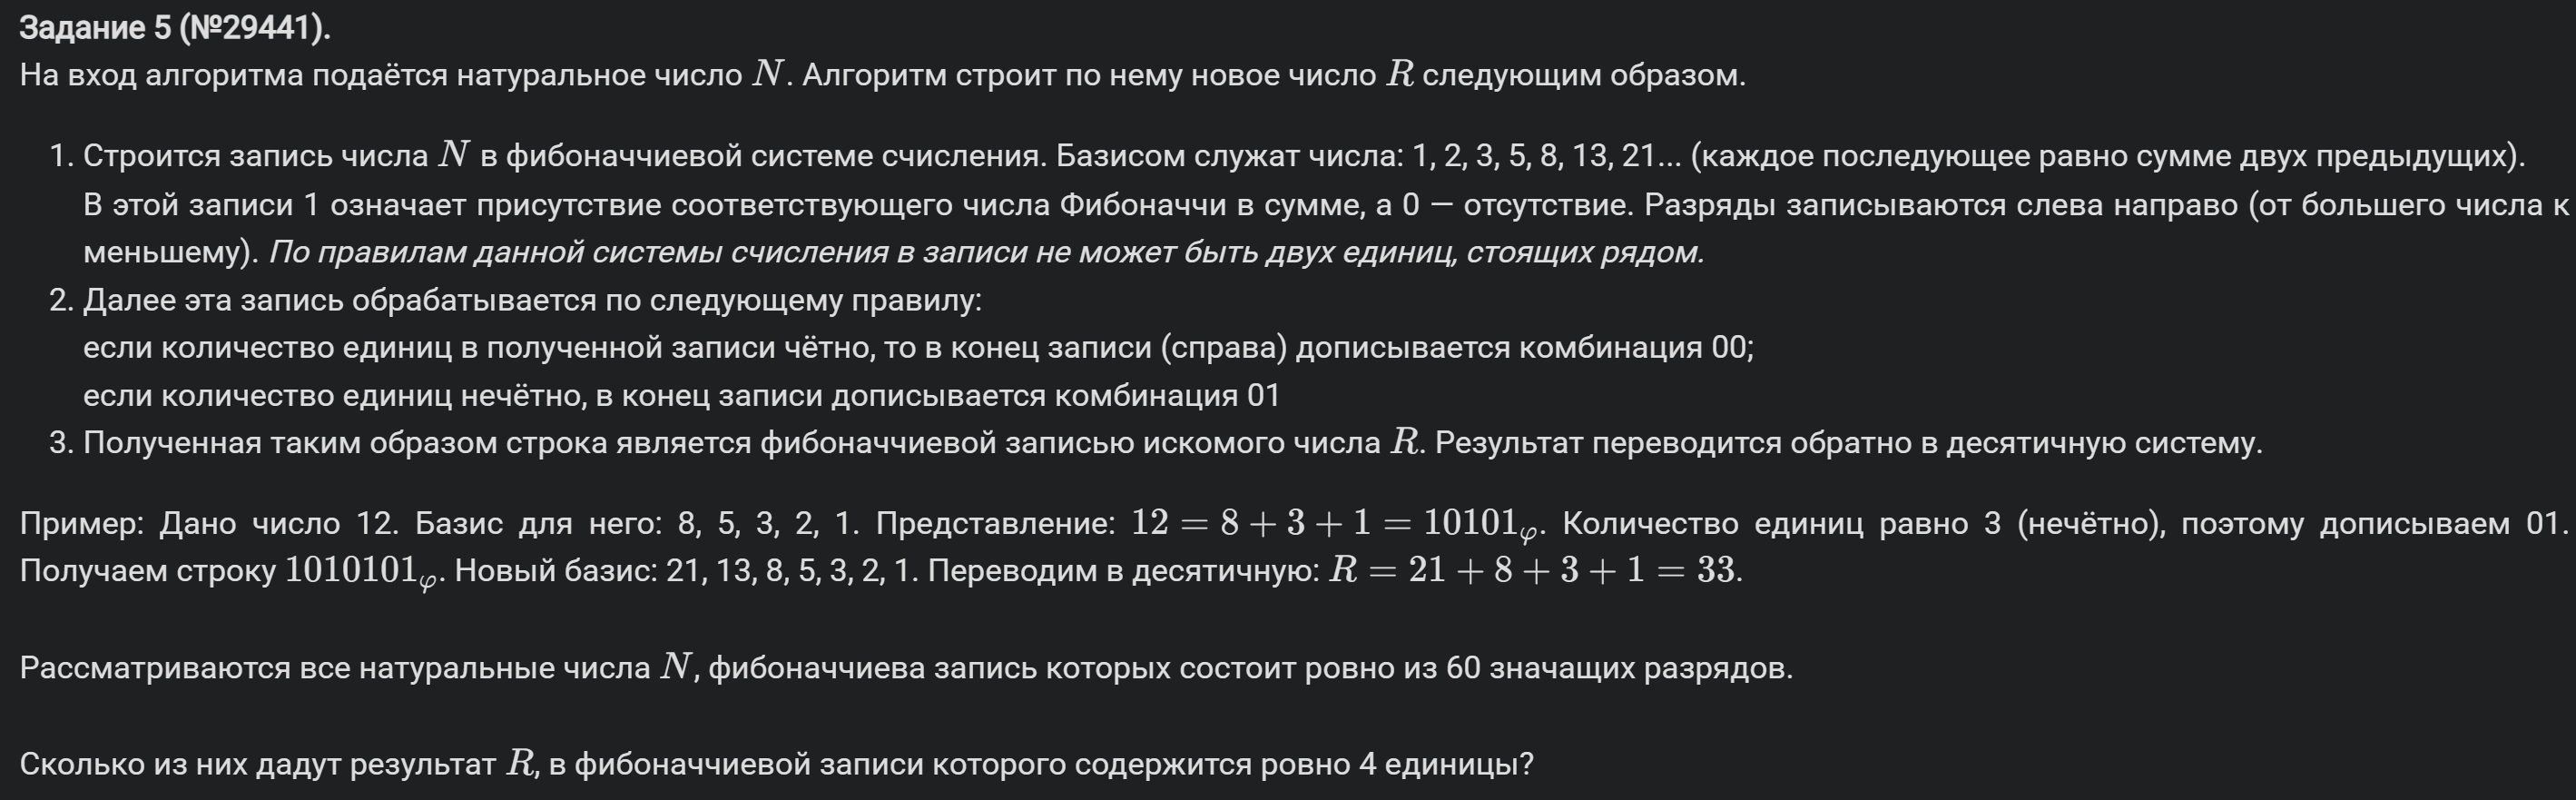

In [7]:
cnt1 = 0
for i1 in range(2, 60):
    for i2 in range(2, 60):
        lst = sorted([i1, i2])
        if lst[1] >= lst[0] + 2:
            cnt1 += 1

cnt2 = 0
for i1 in range(2, 60):
    for i2 in range(2, 60):
        for i3 in range(2, 60):
            lst = sorted([i1, i2, i3])
            if lst[2] >= lst[1] + 2 and lst[1] >= lst[0] + 2:
                cnt2 += 1

print(cnt1 // 2 + cnt2 // 6)

29316


In [9]:
i0 = 0
cnt = 0
for i1 in range(i0 + 2, 60):
    for i2 in range(i1 + 2, 60):
        cnt += 1
        for i3 in range(i2 + 2, 60):
            cnt += 1

print(cnt)

29316


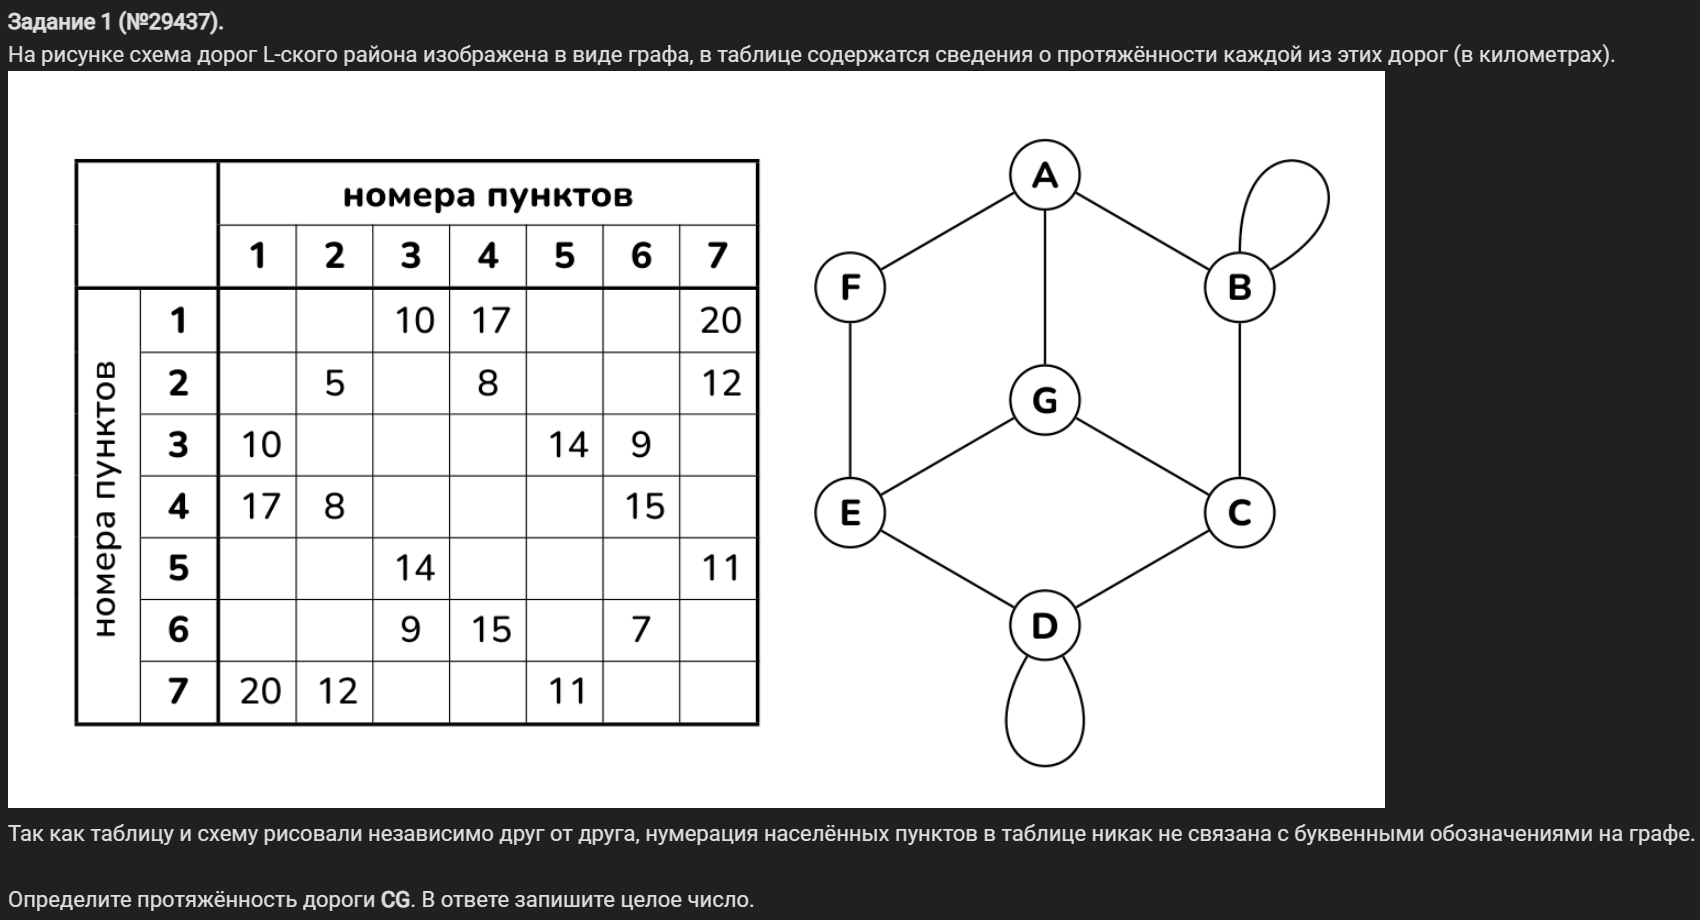

In [10]:
from itertools import *

tab = "347 247 156 126 37 346 125".split(" ")
pic = "fe fa ab bc dc ed eg gc ag dd bb".split(" ")

print(*range(1, 8))
for var in permutations("abcdefg"):
    if all(str(var.index(x) + 1) in tab[var.index(y)] for x, y in pic):
        print(" ".join(var))

1 2 3 4 5 6 7
g b e c f d a
g d a c f b e
